In [1]:
!pip install requests

In [2]:
import torch 
import torch.nn as nn 
import requests 
import zipfile 
from pathlib import Path 
import random 
from PIL import Image
import os 

# 1. Setup Device
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# 2. Setup Paths
data_path = Path("data_/") 
zip_path = data_path / "pizza_steak_sushi.zip" 
dest_dir = data_path / "pizza_steak_sushi"

# 3. Download and Unzip Data
if not dest_dir.is_dir(): 
    print("Downloading and extracting data...") 
    data_path.mkdir(parents=True, exist_ok=True) 
    
    # Download
    response = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip") 
    with open(zip_path, "wb") as f: 
        f.write(response.content) 
        
    # Unzip
    with zipfile.ZipFile(zip_path, "r") as zip_ref: 
        zip_ref.extractall(dest_dir)
        
    # Clean up zip file
    zip_path.unlink()
else: 
    print("Data already exists, skipping download.") 

# 4. Verify Directory Structure
def walk_through_dir(dir_path): 
    for dirpath, dirnames, filenames in os.walk(dir_path): 
        print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.") 

walk_through_dir(dest_dir) 

# 5. Define Train and Test Paths
train_dir = dest_dir / "train" 
test_dir = dest_dir / "test" 

# 6. Grab a Random Image Recursively (Fixed Line)
images = list(train_dir.glob("**/*.jpg")) 
random_image_path = random.choice(images) 
image_class = random_image_path.parent.name
print(f"Randomly selected image: {random_image_path} (Class: {image_class})")

There are 2 directories and 0 images in 'data_/pizza_steak_sushi'.
There are 3 directories and 0 images in 'data_/pizza_steak_sushi/test'.
There are 0 directories and 25 images in 'data_/pizza_steak_sushi/test/pizza'.
There are 0 directories and 31 images in 'data_/pizza_steak_sushi/test/sushi'.
There are 0 directories and 19 images in 'data_/pizza_steak_sushi/test/steak'.
There are 3 directories and 0 images in 'data_/pizza_steak_sushi/train'.
There are 0 directories and 78 images in 'data_/pizza_steak_sushi/train/pizza'.
There are 0 directories and 72 images in 'data_/pizza_steak_sushi/train/sushi'.
There are 0 directories and 75 images in 'data_/pizza_steak_sushi/train/steak'.
Randomly selected image: data_/pizza_steak_sushi/train/pizza/218711.jpg (Class: pizza)


Image size: (382, 512)
Image mode: RGB
Image format: JPEG
Image height: 512
Image width: 382


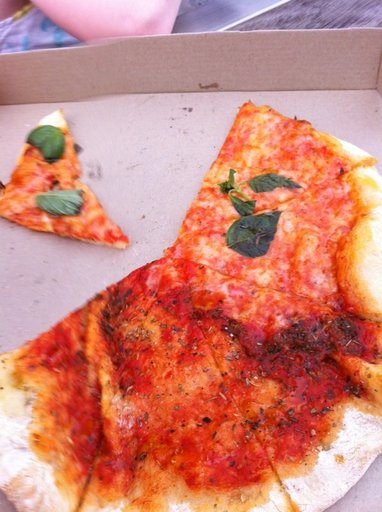

In [3]:
img=Image.open(random_image_path)
# printing metadata of the image
print(f"Image size: {img.size}")
print(f"Image mode: {img.mode}")
print(f"Image format: {img.format}")
print(f"Image height: {img.height}")
print(f"Image width: {img.width}")
img

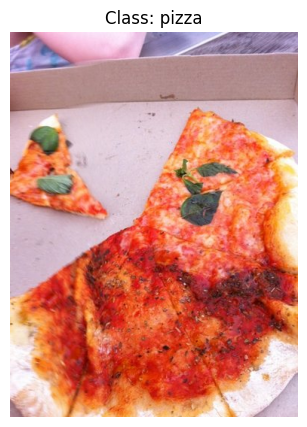

dimensions of the image array: (512, 382, 3)


In [4]:
import numpy as np
import matplotlib.pyplot as plt
img_as_array=np.asarray(img)
plt.figure(figsize=(5,5))
plt.imshow(img_as_array)
plt.title(f"Class: {image_class}")
plt.axis(False)
plt.show()
print("dimensions of the image array:", img_as_array.shape)
# since it has height width and channels but pytorch models expect (channels, height, width) we need to permute the dimensions

In [5]:
# transforming data into tensors
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms,datasets

In [6]:
# write a transofrm fro image
data_transform=transforms.Compose([
    # Resize the image to a fixed size (e.g., 64x64)
    transforms.Resize((64,64)),
    # flip the images randomly
    transforms.RandomHorizontalFlip(p=0.5),
    # turn the image into tensors
    transforms.ToTensor()
])

In [7]:
img_as_array.shape

(512, 382, 3)

In [8]:
data_transform(img).shape

torch.Size([3, 64, 64])

In [9]:
# loading image using ImageFolder
train_data = datasets.ImageFolder(root=train_dir, transform=None)
test_data = datasets.ImageFolder(root=test_dir, transform=data_transform, target_transform=None)

In [10]:
train_data, test_data

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data_/pizza_steak_sushi/train,
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data_/pizza_steak_sushi/test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ))

In [11]:
# get class name as list
class_names = train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [12]:
class_to_idx = train_data.class_to_idx
class_to_idx

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [13]:
len(train_data), len(test_data)

(225, 75)

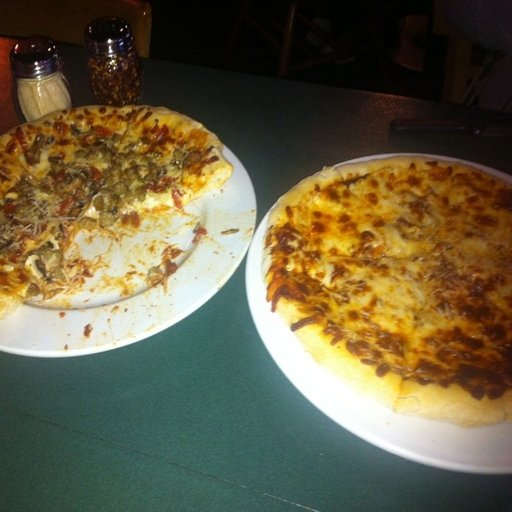

In [14]:
image,label = train_data[0]
image

In [15]:
# turn the loaded images into datasets
from torch.utils.data import Dataset, DataLoader
train_data_loader=DataLoader(train_data, batch_size=32, num_workers=os.cpu_count(), shuffle=True)
test_data_loader=DataLoader(test_data, batch_size=32, num_workers=os.cpu_count(), shuffle=False)

In [16]:
len(train_data_loader), len(test_data_loader)

(8, 3)

In [17]:
# Pass your data_transform here
train_data = datasets.ImageFolder(root=train_dir, transform=data_transform)
test_data = datasets.ImageFolder(root=test_dir, transform=data_transform)

# Re-create the DataLoader
train_data_loader = DataLoader(
    train_data, 
    batch_size=32, 
    num_workers=os.cpu_count(), 
    shuffle=True
)

# This will now work perfectly
img, label = next(iter(train_data_loader))


In [18]:
img.shape   

torch.Size([32, 3, 64, 64])

## creating custom dataloader

In [19]:
from torch.utils.data import Dataset, DataLoader
BATCH_SIZE = 32
train_dataloader = DataLoader(train_data, batch_size=BATCH_SIZE,num_workers=1 ,shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=BATCH_SIZE,num_workers=1 ,shuffle=True)
train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7f02adce9130>,
 <torch.utils.data.dataloader.DataLoader at 0x7f02adcea900>)

In [20]:
len(train_dataloader), len(test_dataloader)

(8, 3)

In [21]:
img,label=next(iter(train_dataloader))

In [25]:
img.shape # (batch_size, channels, height, width)

torch.Size([32, 3, 64, 64])

In [ ]:
#  loading image data with custom dataset class
import os 
import pathlib
import torch
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from typing import Tuple, List,Dict

# all custom datasets should inherit from the Dataset class and override the following methods:
# 1. __init__ : to initialize the dataset object and define any attributes
# 2. __len__ : to return the length of the dataset
# 3. __getitem__ : to retrieve a single data point from the dataset based on


target directory: data_/pizza_steak_sushi


['pizza', 'steak', 'sushi']

In [31]:

print(f"target directory: {dest_dir}")
class_names=sorted([item.name for item in list(os.scandir(train_dir)) if item.is_dir()])
class_names

target directory: data_/pizza_steak_sushi


['pizza', 'steak', 'sushi']

In [ ]:
def find_classes(directory: str) -> Tuple[List[str], Dict[str, int]]:
    """
    Finds the class folders in a dataset.

    Args:
        directory (str): Root directory path.

    Returns:
        Tuple[List[str], Dict[str, int]]: A tuple containing a list of class names and a dictionary mapping class names to indices.
    """
    # Get the class names by listing the directories in the given directory
    classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())
    if not classes:
        raise FileNotFoundError(f"No class folders found in '{directory}'.")
    # Create a mapping from class names to indices
    class_to_idx = {cls_name: idx for idx, cls_name in enumerate(classes)}
    
    return classes, class_to_idx

In [35]:
find_classes(train_dir)

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

In [38]:
class MyImageFolder(Dataset):
    def __init__(self, root_dir: str, transform=None):
        """
        Custom dataset for loading images from a directory.

        Args:
            root_dir (str): Root directory path containing class subdirectories.
            transform (callable, optional): Optional transform to be applied on a sample.
        """
        self.root_dir = pathlib.Path(root_dir)
        self.transform = transform
        self.classes, self.class_to_idx = find_classes(root_dir)
        
        # Gather all image file paths and their corresponding labels
        self.image_paths = []
        self.labels = []
        
        for class_name in self.classes:
            class_dir = self.root_dir / class_name
            for img_path in class_dir.glob("*.jpg"):
                self.image_paths.append(img_path)
                self.labels.append(self.class_to_idx[class_name])
        
    def __len__(self):
        """Returns the total number of samples in the dataset."""
        return len(self.image_paths)

    def __getitem__(self, idx: int):
        """
        Retrieves a sample from the dataset at the given index.

        Args:
            idx (int): Index of the sample to retrieve.
        """
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        
        # Load the image
        image = Image.open(img_path).convert("RGB")
        
        # Apply transformations if any
        if self.transform:
            image = self.transform(image)
        
        return image, label

In [39]:
train_transform=transforms.Compose([
    transforms.Resize((64,64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

test_transform=transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor()
])

In [40]:
# Create instances of the custom dataset
train_dataset = MyImageFolder(root_dir=train_dir, transform=train_transform)
test_dataset = MyImageFolder(root_dir=test_dir, transform=test_transform)
train_dataset, test_dataset

(<__main__.MyImageFolder at 0x7f02ade8a030>,
 <__main__.MyImageFolder at 0x7f02cf776330>)

In [47]:
len(train_dataset), len(test_dataset)

(225, 75)

In [48]:
train_dataset.classes, train_dataset.class_to_idx, test_dataset.classes, test_dataset.class_to_idx

(['pizza', 'steak', 'sushi'],
 {'pizza': 0, 'steak': 1, 'sushi': 2},
 ['pizza', 'steak', 'sushi'],
 {'pizza': 0, 'steak': 1, 'sushi': 2})

In [53]:
train_dataloader_custom=DataLoader(train_dataset, batch_size=BATCH_SIZE, num_workers=1, shuffle=True)
test_dataloader_custom=DataLoader(test_dataset, batch_size=BATCH_SIZE, num_workers=1, shuffle=True)
train_dataloader_custom, test_dataloader_custom

(<torch.utils.data.dataloader.DataLoader at 0x7f02add735c0>,
 <torch.utils.data.dataloader.DataLoader at 0x7f02add70980>)

In [55]:
len(train_dataloader), len(test_dataloader)

(8, 3)

In [56]:
img_custom,label_custom=next(iter(train_dataloader_custom))
img_custom.shape # (batch_size, channels, height, width)

torch.Size([32, 3, 64, 64])

In [58]:
# data augumentation
train_transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()
])

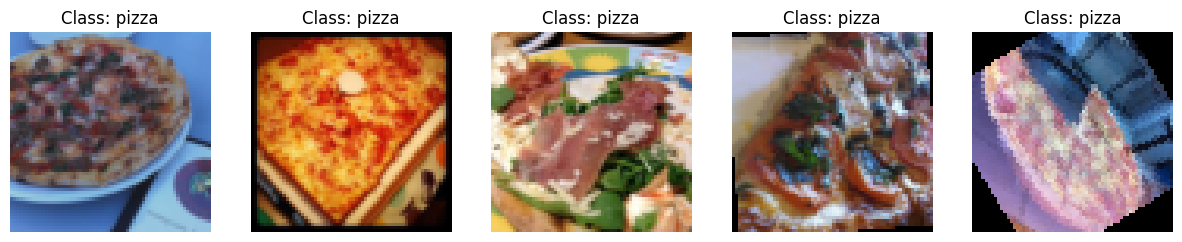

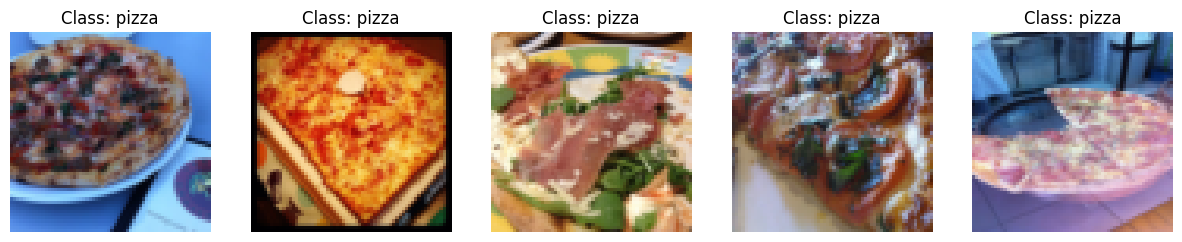

In [61]:
# lets see augumented images
def show_augmented_images(dataset, num_images=5):
    """
    Displays a specified number of augmented images from the dataset.

    Args:
        dataset (Dataset): The dataset from which to sample images.
        num_images (int): The number of images to display.
    """
    plt.figure(figsize=(15, 5))
    
    for i in range(num_images):
        img, label = dataset[i]
        img = img.permute(1, 2, 0)  # Change from (C, H, W) to (H, W, C)
        
        plt.subplot(1, num_images, i + 1)
        plt.imshow(img)
        plt.title(f"Class: {dataset.classes[label]}")
        plt.axis('off')
    
    plt.show()
    
temp_dataset = MyImageFolder(root_dir=train_dir, transform=train_transform)
show_augmented_images(temp_dataset, num_images=5)
show_augmented_images(train_dataset, num_images=5)

In [62]:
# training model
# replicating TinyVGG 
class TinyVGG(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        """
        Initializes the TinyVGG model.

        Args:
            input_shape (int): Number of input channels (e.g., 3 for RGB images).
            hidden_units (int): Number of hidden units in the fully connected layer.
            output_shape (int): Number of output classes.
        """
        super(TinyVGG, self).__init__()
        
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units * 2, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units * 2, out_channels=hidden_units * 2, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=(hidden_units * 2) * 16 * 16, out_features=output_shape)  # Assuming input images are 64x64
        )

    def forward(self, x):
        """
        Defines the forward pass of the model.

        Args:
            x (Tensor): Input tensor.

        Returns:
            Tensor: Output tensor after passing through the model.
        """
        x = self.conv_block_1(x)
        x = self.conv_block_2(x)
        x = self.classifier(x)
        return x



In [63]:
model_tinyVGG=TinyVGG(input_shape=3, hidden_units=10, output_shape=len(train_dataset.classes)).to(device)


In [69]:
# training loop
optimizer = torch.optim.Adam(model_tinyVGG.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()
EPOCHS = 100
for epoch in range(EPOCHS):
    model_tinyVGG.train()
    running_loss = 0.0
    for images, labels in train_dataloader_custom:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model_tinyVGG(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    avg_loss = running_loss / len(train_dataloader_custom)
    if (epoch + 1) % 10 == 0 or epoch == 0:  # Print every 10 epochs and the first epoch
        print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {avg_loss:.4f}")

Epoch [1/100], Loss: 0.5419
Epoch [10/100], Loss: 0.5141
Epoch [20/100], Loss: 0.3433
Epoch [30/100], Loss: 0.2115
Epoch [40/100], Loss: 0.1278
Epoch [50/100], Loss: 0.0587
Epoch [60/100], Loss: 0.1108
Epoch [70/100], Loss: 0.0226
Epoch [80/100], Loss: 0.0086
Epoch [90/100], Loss: 0.0037
Epoch [100/100], Loss: 0.0040


In [71]:
# testing loop
model_tinyVGG.eval()
with torch.inference_mode():
    correct = 0
    total = 0
    for images, labels in test_dataloader_custom:
        images, labels = images.to(device), labels.to(device)
        outputs = model_tinyVGG(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 52.00%


In [72]:
!pip install torchinfo

In [73]:
import torchinfo
torchinfo.summary(model_tinyVGG, input_size=(BATCH_SIZE, 3, 64, 64), col_names=["input_size", "output_size", "num_params", "trainable"])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
TinyVGG                                  [32, 3, 64, 64]           [32, 3]                   --                        True
├─Sequential: 1-1                        [32, 3, 64, 64]           [32, 10, 32, 32]          --                        True
│    └─Conv2d: 2-1                       [32, 3, 64, 64]           [32, 10, 64, 64]          280                       True
│    └─ReLU: 2-2                         [32, 10, 64, 64]          [32, 10, 64, 64]          --                        --
│    └─Conv2d: 2-3                       [32, 10, 64, 64]          [32, 10, 64, 64]          910                       True
│    └─ReLU: 2-4                         [32, 10, 64, 64]          [32, 10, 64, 64]          --                        --
│    └─MaxPool2d: 2-5                    [32, 10, 64, 64]          [32, 10, 32, 32]          --                        --
├─Sequent